<a href="https://colab.research.google.com/github/jof-edu-smc/computational-creativity-ecs7022p/blob/final_in_colab/Ferraro_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installation and Introduction
- This first cell will test to make sure that you are in Google Colab, and run the necessary installations by installing from a python requirements text file.
- The cell also downloads an MIDI analyzer made by https://github.com/Swaminathan-5/MIDI-Maestro-Interactive-MIDI-Analyzer that is used for building chord progressions from the dataset.
- The primary dataset used here is ARIA MIDI developed at Queen Mary University of London: https://huggingface.co/datasets/loubb/aria-midi
- The dataset was modified as you'll see in other slides.
- Checks for GPU (Cuda on Linux), and MPS (Macbook Metal) otherwise, defaults to CPU.


In [4]:
from IPython.display import YouTubeVideo, IFrame, display

# @title Training Video: Quick Start and generate some beats
I_VIDEO_ID = 'ic-VHmadfRs'

if I_VIDEO_ID and I_VIDEO_ID != 'VIDEO_ID':
    # Method 1: Standard YouTubeVideo
    # display(YouTubeVideo(I_VIDEO_ID, width=800, height=450))

    # Method 2: IFrame Embed (often more compatible with Safari tracking protections)
    # Error 153 is often a restricted playback error or a tracking/cookie block in Safari.
    print(f"Loading Video ID: {I_VIDEO_ID}")
    display(IFrame(src=f"https://www.youtube.com/embed/{I_VIDEO_ID}", width=800, height=450))

    print("\nIf you see Error 153 in Safari:")
    print("1. Disable 'Prevent Cross-Site Tracking' in Safari Preferences > Privacy.")
    print(f"2. Or watch directly at: https://www.youtube.com/watch?v={I_VIDEO_ID}")
else:
    print("Please enter a valid YouTube Video ID in the parameter field.")

Loading Video ID: ic-VHmadfRs



If you see Error 153 in Safari:
1. Disable 'Prevent Cross-Site Tracking' in Safari Preferences > Privacy.
2. Or watch directly at: https://www.youtube.com/watch?v=ic-VHmadfRs


In [5]:
from IPython.display import YouTubeVideo

# @title Training Video: How to use Training Mode
T_VIDEO_ID = 't3w5HvlQ3To'

if T_VIDEO_ID and T_VIDEO_ID != 'VIDEO_ID':
    # Method 1: Standard YouTubeVideo
    # display(YouTubeVideo(T_VIDEO_ID, width=800, height=450))

    # Method 2: IFrame Embed (often more compatible with Safari tracking protections)
    # Error 153 is often a restricted playback error or a tracking/cookie block in Safari.
    print(f"Loading Video ID: {T_VIDEO_ID}")
    display(IFrame(src=f"https://www.youtube.com/embed/{T_VIDEO_ID}", width=800, height=450))

    print("\nIf you see Error 153 in Safari:")
    print("1. Disable 'Prevent Cross-Site Tracking' in Safari Preferences > Privacy.")
    print(f"2. Or watch directly at: https://www.youtube.com/watch?v={T_VIDEO_ID}")
else:
    print("Please enter a valid YouTube Video ID in the parameter field.")

Loading Video ID: t3w5HvlQ3To



If you see Error 153 in Safari:
1. Disable 'Prevent Cross-Site Tracking' in Safari Preferences > Privacy.
2. Or watch directly at: https://www.youtube.com/watch?v=t3w5HvlQ3To


In [ ]:
#@title Hyperparameter Configuration
#@markdown <p>If you are planning to train you can make modifications here.</p>
#@markdown <p>Use with caution.</p>
class Opt(object):
  n_epochs = 25 # Number of training epochs.
  batch_size = 32 # Size of the mini-batch for training.
  lr = 2e-4 #0.0001 # Learning rate for the optimizers.
  latent_dim = 100 # Dimension of the latent space vector for the generator.
  min_pitch = 22 # DO NOT MODIFY Minimum MIDI pitch to consider in the dataset.
  max_pitch = 59 # DO NOT MODIFY Maximum MIDI pitch to consider in the dataset.
  w = 16 # DO NOT MODIFY Width of a single musical bar in time steps.
  num_workers = 4 # Number of worker processes for data loading.
  pin_memory = True # Whether to pin memory for DataLoader.
  lambda_1 = 0.01 # DO NOT MODIFY Weight for the raw data feature matching loss.
  lambda_2 = 0.1 # DO NOT MODIFY Weight for the discriminator feature matching loss.
  genre = "" # DO NOT MODIFY The musical genre to train or generate for.
  ckpt_dir = f'checkpoints/{genre}' # DO NOT MODIFY Directory to save model checkpoints.
  pretrained = 'pretrained_models/'
  creativity = 1.0 # Creativity factor for generation (multiplier for latent noise) DEFINITELY MODIFY THIS

opt = Opt()

## MIDInet Style GAN Beat Generator Configurator

In [ ]:
#@title Set the Training and Genre of your beat maker.
#@markdown <h2><font size=5 color=blue>Select whether to Train and your Genre</font></h2>
#@markdown <p><font size=3 color=red><b>Make sure that when you are done training to unselect TRAINING_ON.</b></font></p>
#@markdown <p><font size=3 color=red><b>Training can take up to 2.5hrs training 'all' depending on the config.</b></font></p>
#@markdown <p>Hyperparameters can be modified, but it is not recommended that you modify the noted ones if you don't know what you're doing</p>
#@markdown <p>Approximate times to train for 50 epochs on a Tesla T4 GPU:</p>
#@markdown <ul>
#@markdown   <li><b>All:</b> ~2.5hrs</li>
#@markdown   <li><b>Funk:</b> ~20min</li>
#@markdown   <li><b>Soul:</b> ~10min</li>
#@markdown   <li><b>Hiphop:</b> ~15min</li>
#@markdown   <li><b>Rock:</b> ~35min</li>
#@markdown   <li><b>Jazz:</b> ~10min</li>
#@markdown   <li><b>NewOrleans:</b> ~10min</li>
#@markdown   <li><b>Latin:</b> ~20min</li>
#@markdown   <li><b>Afrocuban:</b> ~20min</li>
#@markdown   <li><b>Punk:</b> ~20min</li>
#@markdown </ul>

TRAINING_ON = False #@param {type:'boolean'}
GENRE = "Funk" #@param ["All", "Funk", "Soul", "Hiphop", "Rock", "Jazz", "NewOrleans", "Latin", "Afrocuban", "Punk" ]

opt.genre = GENRE.lower()
opt.ckpt_dir = f'checkpoints/{opt.genre}'
#@markdown <hr style='margin: 20px 0;'>
#@markdown <h2><font size=5 color=blue>How many bars do you want to generate?</font></h2>
NUM_BARS_TO_GENERATE = 10 #@param {type:'slider', min:'0', max:'100', step:'1'}
#@markdown <p><font size=2 color=red>Make sure there are no whitespaces in the file name</font></p>
MIDI_FILENAME = "generated_sample" #@param {type:'string'}
MIDI_FILENAME = MIDI_FILENAME.replace(" ", "_").strip()
CREATIVITY = 1.0 #@param {type:'slider', min:'0.0', max:'2.0', step:'0.1'}
opt.creativity = float(CREATIVITY)
#@markdown <hr style='margin: 20px 0;'>
#@markdown <p>Click <b>Run all</b> when ready</p>

In [ ]:
#@title Requirements
#@markdown Sets the requirements for the package installer for Python
requirements = """
numpy
pandas
scipy
matplotlib
seaborn
tqdm
torch
torchaudio
torchvision
tensorboard
lightning
lightning-utilities
midi2audio
pretty_midi
tensorboardX
torchmetrics
torchsummary
"""

In [ ]:
#@title Imports and Downloads
#@markdown This will import and download the necessary packages, datasets and libraries to run the GAN.

import subprocess
import os
import shutil
import gdown

try:
    import google.colab  # noqa: F401
    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    with open('requirements.txt', 'w') as f:
        f.write(requirements.strip())
        f.close()

    if not shutil.which('fluidsynth'):
      clear_output()
      print("Fluidsynth not found. Installing...")
      os.system('apt-get update -y && apt-get install -y fluidsynth')

    # if not os.path.isfile('enhanced_midi_analyzer.py'):
    #   !apt-get install -y wget
    #   !wget -q https://raw.githubusercontent.com/Swaminathan-5/MIDI-Maestro-Interactive-MIDI-Analyzer/refs/heads/main/enhanced_midi_analyzer.py
    if not os.path.isfile('FluidR3Mono_GM.sf3'):
        !wget -q https://github.com/musescore/MuseScore/raw/2.1/share/sound/FluidR3Mono_GM.sf3

    if not os.path.isfile('./groove_dataset/groove/info.csv') and TRAINING_ON:
      # './aria-midi-v1-deduped-ext/metadata.json'
      # !wget https://huggingface.co/datasets/loubb/aria-midi/resolve/main/aria-midi-v1-deduped-ext.tar.gz?download=true
      # !tar -xzf aria-midi-v1-deduped-ext.tar.gz?download=true
      url = 'https://storage.googleapis.com/magentadata/datasets/groove/groove-v1.0.0-midionly.zip'
      zip_filename = 'groove-v1.0.0-midionly.zip'
      target_dir = 'groove_dataset'

      subprocess.run(
          ["curl", "-o", zip_filename, url],
          check=True,
          capture_output=True # Hides the messy curl progress bar in Colab/Jupyter
      )

      # 2. Create the destination directory
      os.makedirs(target_dir, exist_ok=True)

      # 3. Extract the file using unzip
      # The -q flag keeps it quiet so it doesn't print all 1,000+ filenames
      # The -o flag overwrites existing files without asking for a prompt
      print("Extracting Dataset Files...")
      subprocess.run(
          ["unzip", "-q", "-o", zip_filename, "-d", target_dir],
          check=True
      )

      # 4. Clean up the leftover zip file to save space
      if os.path.exists(zip_filename):
          os.remove(zip_filename)

      print(f"Success! Dataset extracted to ./{target_dir}/")
      # !wget https://storage.googleapis.com/magentadata/datasets/groove/groove-v1.0.0-midionly.zip
      # !tar -xzf groove-v1.0.0-midionly.zip
    if not os.path.isdir('pretrained_models') or not TRAINING_ON:
        # Google Drive share link
        google_drive_link = 'https://drive.google.com/file/d/1wu-9eFBdTx2ZPUF_SthB50DLO3dGPy83/view?usp=share_link'

        # Extract the file ID from the link
        file_id = google_drive_link.split('/')[-2]
        output_filename = 'pretrained_models.zip'

        gdown.download(google_drive_link, output_filename, quiet=False, fuzzy=True)

        subprocess.run(
              ["unzip", "-q", "-o", output_filename, "-d", 'pretrained_models'],
              check=True
          )

    musescore_path = shutil.which('musescore3')

    if musescore_path:
        print(f"MuseScore 3 is installed at: {musescore_path}")
    else:
        clear_output()
        print("MuseScore 3 is not found in your system's PATH.")

        !apt install musescore3

    !pip install -r requirements.txt

!python --version
from IPython.display import clear_output
clear_output()

from statistics import mean, median
import librosa
import pretty_midi
import ipywidgets as widgets
import random
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import logging
import time
import midi2audio
import IPython.display as ipd
from torch.utils.data import random_split
import itertools

# from enhanced_midi_analyzer import EnhancedMIDIAnalyzer, CHORD_TYPES, logger
# logger.setLevel(logging.WARNING)

if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using GPU:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon GPU (MPS)")
else:
    device = torch.device('cpu')
    print("Using CPU")

Using GPU: Tesla T4


### This is a helper Plotter function for plotting midi data and melodies.

In [ ]:
#@title Plot MIDI Data with PrettyMIDI
#@markdown <p>This is a helper function used throughout the notebook to plot the Piano Roll</p>

def plot_midi(file_path, fs=100, title="Piano Roll with C-Octave Markers"):
    %matplotlib inline
    if isinstance(file_path, pretty_midi.PrettyMIDI):
        pm = file_path
    else:
        if file_path.endswith('.mid') and os.path.isfile(file_path):
            pm = pretty_midi.PrettyMIDI(file_path)
        else:
            raise FileNotFoundError(f"{file_path} is not a valid MIDI file.")

    fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=(16, 8))
    pitched_notes = [note for instrument in pm.instruments if not instrument.is_drum for note in instrument.notes]
    drum_notes = [note for instrument in pm.instruments if instrument.is_drum for note in instrument.notes]

    if pitched_notes:
        roll = pm.get_piano_roll(fs=fs)
        img = librosa.display.specshow(
            roll,
            hop_length=1,
            sr=fs,
            ax=ax
        )
        y_min, y_max = 24, 108
        y_ticks = np.arange(24, 109, 12)

    elif drum_notes:
        end_time = max((note.end for note in drum_notes), default=0.0)
        n_frames = max(1, int(np.ceil(end_time * fs)) + 1)
        roll = np.zeros((128, n_frames), dtype=np.float32)
        for note in drum_notes:
            start_idx = max(0, int(np.floor(note.start * fs)))
            end_idx = max(start_idx + 1, int(np.ceil(note.end * fs)))
            end_idx = min(end_idx, n_frames)
            roll[note.pitch, start_idx:end_idx] = max(roll[note.pitch, start_idx:end_idx].max(), float(note.velocity))
        img = ax.imshow(roll, aspect='auto', origin='lower', cmap='magma', interpolation='nearest')
        y_min, y_max = 0, 127
        y_ticks = np.arange(0, 128, 12)

    else:
        raise ValueError("This MIDI file contains no notes to plot.")

    c_labels = [f"C{(m // 12) - 1}" for m in y_ticks]
    ax.set_yticks(y_ticks)
    # ax.set_yticklabels(c_labels)

    xtick_positions = np.arange(0, roll.shape[1], max(1, fs * 2))
    xtick_labels = (xtick_positions / fs).astype(int)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('MIDI pitch')

    for m in y_ticks:
        if y_min <= m <= y_max:
            ax.axhline(m, color='white', alpha=0.15, linewidth=0.8)

    ax.set_title(f"{title}: {'Drum Roll' if drum_notes and not pitched_notes else 'Instrument'}")
    fig.tight_layout()
    plt.show()
    return 'Printed the piano roll plot successfully.'


In [ ]:
#@title Groove Dataset Module
#@markdown <p>This is the a Dataset Module that utilizes torch.utils.Dataset to prepare and quantize and preprocess the Google Grooveset Dataset</p>
#@markdown <p>The dataset should theoretically pull already quantized apple loops from your library if you have the MIDI files available.</p>
import csv
import hashlib
from pathlib import Path

class GrooveDataset(Dataset):
    def __init__(
        self,
        data_dir,
        pt_dir='./processed_tensors',
        device='cpu',
        split='train',
        genre_filter='all',
        include_apple_loops=True,
        apple_loops_dir='./test_midi',
    ):
        self.data_dir = data_dir
        self.pt_dir = pt_dir
        self.device = torch.device(device)
        self.split = split
        self.genre_filter = genre_filter.lower()
        self.include_apple_loops = include_apple_loops
        self.apple_loops_dir = apple_loops_dir

        self.pt_train = os.path.join(self.pt_dir, 'train')
        self.pt_eval = os.path.join(self.pt_dir, 'eval')
        os.makedirs(self.pt_train, exist_ok=True)
        os.makedirs(self.pt_eval, exist_ok=True)

        self.train_files = []
        self.eval_files = []
        self.train_bars = []
        self.eval_bars = []
        self.genres = {}

        manifest = []
        manifest.extend(self._collect_groove_manifest())
        if self.include_apple_loops:
            manifest.extend(self._collect_apple_loops_manifest(self.apple_loops_dir))

        if self.genre_filter != 'all':
            manifest = [m for m in manifest if m['genre'].lower() == self.genre_filter]

        for item in manifest:
            if item['split'] == 'train':
                self.train_files.append(item)
            else:
                self.eval_files.append(item)

        for item in tqdm(self.train_files, desc='Processing training MIDI files'):
            bars = self._process_entry(item)
            self._save_bars(bars, item, target_split='train')

        for item in tqdm(self.eval_files, desc='Processing evaluation MIDI files'):
            bars = self._process_entry(item)
            self._save_bars(bars, item, target_split='eval')

    def _collect_groove_manifest(self):
        manifest = []
        info_csv = Path(self.data_dir) / 'groove' / 'info.csv'
        if not info_csv.exists():
            return manifest

        with open(info_csv, 'r') as f:
            reader = csv.reader(f)
            _ = next(reader)
            for row in reader:
                file_id = row[7]
                genre = row[3].split('/')[0]
                bpm = int(row[4])
                ts = row[6]
                split = 'eval' if row[-1] == 'test' else 'train'

                self.genres[genre] = self.genres.get(genre, 0) + 1
                if '4-4.mid' not in file_id:
                    split = 'eval'

                manifest.append({
                    'source': 'groove',
                    'path': os.path.join(self.data_dir, 'groove', file_id),
                    'rel_id': file_id,
                    'genre': genre,
                    'bpm': bpm,
                    'time_signature': ts,
                    'split': split,
                })
        return manifest

    def _collect_apple_loops_manifest(self, apple_loops_dir):
        manifest = []
        root = Path(apple_loops_dir)
        if not root.exists():
            return manifest

        for genre_dir in root.iterdir():
            if not genre_dir.is_dir():
                continue
            genre = genre_dir.name
            self.genres[genre] = self.genres.get(genre, 0) + 0

            for midi_path in genre_dir.glob('*.mid'):
                digest = int(hashlib.md5(str(midi_path).encode()).hexdigest(), 16)
                split = 'eval' if (digest % 10) < 2 else 'train'
                manifest.append({
                    'source': 'apple_loops',
                    'path': str(midi_path),
                    'rel_id': f'{genre}/{midi_path.name}',
                    'genre': genre,
                    'bpm': None,
                    'time_signature': None,
                    'split': split,
                })
        return manifest

    def _process_entry(self, item):
        if item['source'] == 'groove':
            return self.process_midi_to_tensor_list(
                midi_path=item['path'],
                target_bpm=item['bpm'],
                time_signature=item['time_signature'],
                stride=4,
            )
        return self.process_midi_no_quantize_to_tensor_list(
            midi_path=item['path'],
            stride=4,
        )

    def process_midi_no_quantize_to_tensor_list(self, midi_path, stride=16):
        """
        Convert non-Groove MIDI files without Groove-specific quantization.
        """
        midi_data = pretty_midi.PrettyMIDI(midi_path)

        tempo = max(1.0, midi_data.estimate_tempo())
        step_duration = (60.0 / tempo) / 4.0

        max_end_time = 0.0
        for instrument in midi_data.instruments:
            if instrument.is_drum:
                for note in instrument.notes:
                    max_end_time = max(max_end_time, note.end)

        total_steps = int(np.ceil(max_end_time / step_duration))
        if total_steps < 16:
            return []

        master_matrix = np.zeros((128, total_steps), dtype=np.float32)
        for instrument in midi_data.instruments:
            if not instrument.is_drum:
                continue
            for note in instrument.notes:
                start_bin = int(np.floor(note.start / step_duration))
                end_bin = int(np.ceil(note.end / step_duration))
                if end_bin <= start_bin:
                    end_bin = start_bin + 1
                start_bin = min(max(0, start_bin), total_steps - 1)
                end_bin = min(max(1, end_bin), total_steps)
                master_matrix[note.pitch, start_bin:end_bin] = 1.0

        tensor_list = []
        for start_idx in range(0, total_steps - 15, stride):
            bar_slice = master_matrix[:, start_idx:start_idx + 16]
            bar_tensor = torch.from_numpy(bar_slice).unsqueeze(0).to(self.device)
            tensor_list.append(bar_tensor)

        return tensor_list

    def _save_bars(self, bars, item, target_split):
        target_dir = self.pt_train if target_split == 'train' else self.pt_eval
        stem = Path(item['path']).stem
        source_tag = item['source']
        genre_tag = item['genre'].replace(' ', '_')

        for index, bar in enumerate(bars):
            bar_path = os.path.join(target_dir, f'{source_tag}_{genre_tag}_{stem}_bar{index}.pt')
            torch.save({
                'bar': bar,
                'bar_path': bar_path,
                'src_midi_file': item['path'],
                'source': item['source'],
                'genre': item['genre'],
                'bpm': item['bpm'],
                'time_signature': item['time_signature'],
            }, bar_path)

            if target_split == 'train':
                self.train_bars.append(bar_path)
            else:
                self.eval_bars.append(bar_path)

    def _get_split_bar_paths(self):
        if self.split == 'train':
            return self.train_bars
        if self.split == 'eval':
            return self.eval_bars
        raise ValueError(f"Unknown split '{self.split}'. Expected 'train' or 'eval'.")

    def with_split(self, split):
        clone = object.__new__(GrooveDataset)
        clone.__dict__ = self.__dict__.copy()
        clone.split = split
        return clone

    def process_midi_to_tensor_list(self, midi_path, target_bpm=None, time_signature=None, stride=16):
        """
        Extracts overlapping 1-bar chunks from a MIDI file.
        Returns: A list of PyTorch tensors, each with shape (1, 128, 16).
        """
        if target_bpm is None or time_signature is None:
            raise ValueError("Both target_bpm and time_signature must be provided together for accurate slicing.")

        try:
            midi_data = pretty_midi.PrettyMIDI(midi_path)
        except Exception as e:
            return f"Error processing {midi_path}: {str(e)}"

        tempo = target_bpm if target_bpm else midi_data.estimate_tempo()
        step_duration = (60.0 / tempo) / float(time_signature[0])
        max_end_time = 0
        for instrument in midi_data.instruments:
            if instrument.is_drum:
                for note in instrument.notes:
                    if note.end > max_end_time:
                        max_end_time = note.end

        total_steps = int(np.ceil(max_end_time / step_duration))
        if total_steps < 16:
            return []

        master_matrix = np.zeros((128, total_steps), dtype=np.float32)
        for instrument in midi_data.instruments:
            if not instrument.is_drum:
                continue
            for note in instrument.notes:
                start_bin = int(np.round(note.start / step_duration))
                end_bin = int(np.round(note.end / step_duration))
                if start_bin == end_bin:
                    end_bin += 1
                start_bin = min(max(0, start_bin), total_steps - 1)
                end_bin = min(max(1, end_bin), total_steps)
                for t in range(start_bin, end_bin):
                    master_matrix[note.pitch, t] = 1.0

        tensor_list = []
        for start_idx in range(0, total_steps - 15, stride):
            bar_slice = master_matrix[:, start_idx:start_idx + 16]
            bar_tensor = torch.from_numpy(bar_slice).unsqueeze(0).to(self.device)
            tensor_list.append(bar_tensor)

        return tensor_list

    def __len__(self):
        return len(self._get_split_bar_paths())

    def __getitem__(self, idx):
        bar_path = self._get_split_bar_paths()[idx]
        if idx == 0:
            condition_bar_path = self._get_split_bar_paths()[0]
            condition_bar = torch.load(condition_bar_path, map_location=self.device)
        else:
            condition_bar_path = self._get_split_bar_paths()[idx - 1]
            condition_bar = torch.load(condition_bar_path, map_location=self.device)
        real_bar = torch.load(bar_path, map_location=self.device)
        return real_bar, condition_bar



def save_gan_tensor_to_drums(tensor_input, output_path="gan_drums.mid", bpm=120):
        """
        Converts GAN output into a Groove-compatible MIDI file of ANY length.
        Accepts:
        - A single 2D tensor: (128, 16)
        - A batched 3D/4D tensor: (N, 1, 128, 16)
        - A Python list of tensors: [tensor1, tensor2, ...]
        """
        if isinstance(tensor_input, list):
            matrices = [t.detach().squeeze().cpu().numpy() for t in tensor_input]
            matrix = np.concatenate(matrices, axis=1)
        elif torch.is_tensor(tensor_input):
            t = tensor_input.detach().squeeze().cpu()
            if t.ndim == 3:
                matrix = t.permute(1, 0, 2).reshape(128, -1).numpy()
            elif t.ndim == 2:
                matrix = t.numpy()
            else:
                raise ValueError(f"Unexpected tensor shape: {tensor_input.shape}")
        else:
            raise TypeError("Input must be a PyTorch tensor or a list of tensors.")

        num_pitches, total_steps = matrix.shape
        drum_midi = pretty_midi.PrettyMIDI(initial_tempo=bpm)
        drum_track = pretty_midi.Instrument(program=0, is_drum=True, name="GAN Drum Kit")
        step_duration = (60.0 / bpm) / 4.0

        for pitch in range(num_pitches):
            for step in range(total_steps):
                if matrix[pitch, step] > 0.5:
                    start_time = step * step_duration
                    end_time = start_time + step_duration
                    note = pretty_midi.Note(
                        velocity=100,
                        pitch=pitch,
                        start=start_time,
                        end=end_time
                    )
                    drum_track.notes.append(note)

        drum_midi.instruments.append(drum_track)
        drum_midi.write(output_path)
        return output_path


# GAN (Based on MIDInet)

## Training Setup

### Model Definition
- `standard_gan_loss(D_out_real, D_out_fake)`: Computes the standard BCE minimax GAN losses for both models. It returns discriminator loss (`D_loss`) and generator BCE loss (`G_loss_bce`).
- `feature_matching_loss(real_data, fake_data, f_real, f_fake, lambda_1, lambda_2)`: Adds a stability objective by matching batch-level statistics between real and generated data, both in raw space and discriminator feature space.
- `weights_init_normal(m)`: Initializes Conv/Linear weights with a normal distribution (`mean=0`, `std=0.02`) and BatchNorm with DCGAN-style initialization (`mean=1`, `std=0.02`).
- `Generator`: Produces a drum/piano-roll bar from latent noise and conditioner features (`c4, c3, c2, c1`). If chord conditioning is enabled (`chord_dim > 0`), chord vectors are projected and fused at each upsampling stage.
- `Discriminator`: Classifies bars as real/fake and optionally returns intermediate features for feature matching. It can concatenate chord conditioning channels when `chord_dim > 0`.
- `Conditioner`: Encodes the previous/conditioning bar with Conv2D layers and returns a multiscale feature pyramid (`c4, c3, c2, c1`) used by the generator during upsampling.

In [ ]:
#@title Model Architecture
import torch
from torch import nn

def standard_gan_loss(D_out_real, D_out_fake):
    """Standard Minimax BCE Loss for GANs"""
    criterion = nn.BCELoss()

    # Create target tensors filled with 1s (real) and 0s (fake)
    real_targets = torch.ones_like(D_out_real)
    fake_targets = torch.zeros_like(D_out_fake)

    # Discriminator loss: How well did it classify real as 1 and fake as 0?
    D_loss_real = criterion(D_out_real, real_targets)
    D_loss_fake = criterion(D_out_fake, fake_targets)
    D_loss = D_loss_real + D_loss_fake

    # Generator loss: How well did it trick the Discriminator into guessing 1?
    G_loss_bce = criterion(D_out_fake, real_targets)

    return D_loss, G_loss_bce

def feature_matching_loss(real_data, fake_data, f_real, f_fake, lambda_1=0.1, lambda_2=1.0):
    """
    Implements Equation 2 from the MidiNet paper:
    lambda_1 || E[X] - E[G(z)] ||^2_2 + lambda_2 || E[f(X)] - E[f(G(z))] ||^2_2
    """
    # Calculate Expectations (mean across the batch dimension)
    mean_real = torch.mean(real_data, dim=0)
    mean_fake = torch.mean(fake_data, dim=0)

    mean_f_real = torch.mean(f_real, dim=0)
    mean_f_fake = torch.mean(f_fake, dim=0)

    # Calculate Squared L2 Norms
    l2_raw_data = torch.sum((mean_real - mean_fake) ** 2)
    l2_features = torch.sum((mean_f_real - mean_f_fake) ** 2)

    return (lambda_1 * l2_raw_data) + (lambda_2 * l2_features)

def weights_init_normal(m):
    """
    Applies a zero-centered normal distribution (std=0.02) to the weights
    of Convolutional, Transposed Convolutional, and Linear layers.
    """
    classname = m.__class__.__name__

    # Check if the layer is a Conv, ConvTranspose, or Linear layer
    if classname.find('Conv') != -1 or classname.find('Linear') != -1:
        # Initialize weights to mean=0.0, std=0.02
        nn.init.normal_(m.weight.data, mean=0.0, std=0.02)

        # If the layer has a bias, initialize it to 0
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)

    # For Batch Normalization layers, it is standard DCGAN practice
    # to center the weights at 1.0 rather than 0.0, with the same std.
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, mean=1.0, std=0.02)
        nn.init.constant_(m.bias.data, 0.0)

class Generator(nn.Module):
    def __init__(self, latent_dim=100, chord_dim=13, min_pitch=48, max_pitch=72, w=16):
        super(Generator, self).__init__()

        self.min_pitch = min_pitch
        self.max_pitch = max_pitch
        self.w = w
        self.pitch_slice = slice(min_pitch, max_pitch + 1)
        self.pitch_height = max_pitch - min_pitch + 1

        # --- NEW: Architectural Toggle ---
        self.chord_dim = chord_dim
        self.use_chords = chord_dim > 0

        # Only initialize chord projection layers if we are actually using chords
        if self.use_chords:
            self.chord_proj_step1 = nn.Linear(chord_dim, 1 * 1 * 2)
            self.chord_proj_step2 = nn.Linear(chord_dim, 1 * 1 * 4)
            self.chord_proj_step3 = nn.Linear(chord_dim, 1 * 1 * 8)
            self.chord_proj_step4 = nn.Linear(chord_dim, 1 * 1 * 16)

        # FC1 dynamically adjusts its input size
        self.fc1 = nn.Linear(latent_dim + chord_dim, 1024)
        self.fc2 = nn.Linear(1024, 512)

        # --- CHANNEL MATH ---
        # Base channels: 256 (from x) + 256 (from conditions) = 512
        # If chords are used, we project them into 1 extra channel = 513
        transconv_in_channels = 513 if self.use_chords else 512

        self.transconv1 = nn.ConvTranspose2d(transconv_in_channels, 256, kernel_size=(1, 2), stride=(1, 2))
        self.transconv2 = nn.ConvTranspose2d(transconv_in_channels, 256, kernel_size=(1, 2), stride=(1, 2))
        self.transconv3 = nn.ConvTranspose2d(transconv_in_channels, 256, kernel_size=(1, 2), stride=(1, 2))
        self.transconv4 = nn.ConvTranspose2d(transconv_in_channels, 1, kernel_size=(self.pitch_height, 1), stride=(1, 1))

        self.bn1 = nn.BatchNorm2d(256)
        self.bn2 = nn.BatchNorm2d(256)
        self.bn3 = nn.BatchNorm2d(256)

        self.relu = nn.LeakyReLU(0.2, inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, z, c4=None, c3=None, c2=None, c1=None, chords=None):
        if c4 is None or c3 is None or c2 is None or c1 is None:
            raise ValueError("All four condition layers (c4, c3, c2, c1) must be provided.")

        batch_size = z.size(0)

        # --- Latent Combination ---
        if self.use_chords:
            if chords is None:
                raise ValueError("Generator was initialized with chord_dim > 0, but no chords were provided.")
            chords = chords.squeeze(-1) if chords.ndim > 2 else chords
            z_combined = torch.cat([z, chords], dim=1)
        else:
            z_combined = z

        x = self.relu(self.fc1(z_combined))
        x = self.relu(self.fc2(x))

        # Reshape to (batch, 256, 1, 2)
        x = x.view(batch_size, 256, 1, 2)

        # --- Step 1 ---
        if self.use_chords:
            proj_c1 = self.chord_proj_step1(chords).view(batch_size, 1, 1, 2)
            x = torch.cat([x, c4, proj_c1], dim=1)
        else:
            x = torch.cat([x, c4], dim=1)

        x = self.relu(self.bn1(self.transconv1(x)))

        # --- Step 2 ---
        if self.use_chords:
            proj_c2 = self.chord_proj_step2(chords).view(batch_size, 1, 1, 4)
            x = torch.cat([x, c3, proj_c2], dim=1)
        else:
            x = torch.cat([x, c3], dim=1)

        x = self.relu(self.bn2(self.transconv2(x)))

        # --- Step 3 ---
        if self.use_chords:
            proj_c3 = self.chord_proj_step3(chords).view(batch_size, 1, 1, 8)
            x = torch.cat([x, c2, proj_c3], dim=1)
        else:
            x = torch.cat([x, c2], dim=1)

        x = self.relu(self.bn3(self.transconv3(x)))

        # --- Step 4 ---
        if self.use_chords:
            proj_c4 = self.chord_proj_step4(chords).view(batch_size, 1, 1, 16)
            x = torch.cat([x, c1, proj_c4], dim=1)
        else:
            x = torch.cat([x, c1], dim=1)

        x = self.transconv4(x)

        x = self.sigmoid(x)
        return x.squeeze(1)


class Discriminator(nn.Module):
    def __init__(self, chord_dim=13, min_pitch=48, max_pitch=72, w=16):
        super(Discriminator, self).__init__()

        self.min_pitch = min_pitch
        self.max_pitch = max_pitch
        self.w = w
        self.pitch_slice = slice(min_pitch, max_pitch + 1)
        self.pitch_height = max_pitch - min_pitch + 1

        self.chord_dim = chord_dim
        self.use_chords = chord_dim > 0

        # Input channels: 1 (for the piano roll) + 13 (if chords are used)
        conv1_in_channels = 1 + chord_dim

        # First conv: 14 filters, 128x2 kernel, stride 2
        self.conv1 = nn.Conv2d(conv1_in_channels, 14, kernel_size=(self.pitch_height, 2), stride=(1, 2), padding=0)

        # Second conv: 77 filters, 1x4 kernel, stride 2
        self.conv2 = nn.Conv2d(14, 77, kernel_size=(1, 4), stride=(1, 2), padding=0)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(77 * 1 * 3, 1024)
        self.fc2 = nn.Linear(1024, 1)

        self.batchnorm2 = nn.BatchNorm2d(77)

        self.relu = nn.LeakyReLU(0.2, inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, bar, chord_condition=None, return_features=False):
        if bar.shape[1] != 1:
            bar = bar.unsqueeze(1)

        batch_size = bar.size(0)

        if self.use_chords:
            if chord_condition is None:
                raise ValueError("Discriminator requires chord conditioning, but none was provided.")
            # Dynamically use self.chord_dim instead of hardcoded 13
            chords_expanded = chord_condition.view(batch_size, self.chord_dim, 1, 1).expand(-1, -1, self.pitch_height, 16)
            bar = torch.cat([bar, chords_expanded], dim=1)

        # We isolate the output of conv1 so we can use it for feature matching
        f1 = self.relu(self.conv1(bar))
        x = self.relu(self.conv2(f1))
        x = self.batchnorm2(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        out = self.sigmoid(self.fc2(x))

        out = out.squeeze(1)

        if return_features:
            return out, f1
        return out

class Conditioner(nn.Module):
    def __init__(self, min_pitch=48, max_pitch=72, w=16):
        super(Conditioner, self).__init__()
        # The Conditioner uses standard Conv2d to shrink the matrix.
        # Input shape: (batch, 1, 128, 16)
        self.min_pitch = min_pitch
        self.max_pitch = max_pitch
        self.w = w
        self.pitch_slice = slice(min_pitch, max_pitch + 1)
        self.pitch_height = max_pitch - min_pitch + 1
        # 1. Input is [batch, 1, pitch_height, w]
        self.conv1 = nn.Conv2d(1, 256, kernel_size=(self.pitch_height, 1), stride=(1, 1))  # -> (batch, 256, 1, 16)

        # 2. Start halving the width.
        self.conv2 = nn.Conv2d(256, 256, kernel_size=(1, 2), stride=(1, 2))  # -> (batch, 256, 1, 8)
        self.conv3 = nn.Conv2d(256, 256, kernel_size=(1, 2), stride=(1, 2))  # -> (batch, 256, 1, 4)
        self.conv4 = nn.Conv2d(256, 256, kernel_size=(1, 2), stride=(1, 2))  # -> (batch, 256, 1, 2)

        self.bn1 = nn.BatchNorm2d(256)
        self.bn2 = nn.BatchNorm2d(256)
        self.bn3 = nn.BatchNorm2d(256)

        self.relu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        # x is the 2D condition (e.g., the melody of the previous bar)
        # Ensure x has the channel dimension: (batch, 1, 128, 16)
        if len(x.shape) == 3:
            x = x.unsqueeze(1)

        c1 = self.relu(self.bn1(self.conv1(x)))    # Shape: (..., 1, 16)
        c2 = self.relu(self.bn2(self.conv2(c1)))   # Shape: (..., 1, 8)
        c3 = self.relu(self.bn3(self.conv3(c2)))   # Shape: (..., 1, 4)

        # The deepest layer
        c4 = self.relu(self.conv4(c3))             # Shape: (..., 1, 2)

        # Return them in reverse order so they easily pair with the
        # Generator's transposed convolutions (which start small and grow large).
        return c4, c3, c2, c1



In [ ]:
#@title Training Function
def train(generator, conditioner, discriminator,
          train_dataloader, val_dataloader,
          generator_optimizer, discriminator_optimizer,
          opt, device, checkpoint_dir='checkpoints'):
    best_val_g_fm = float('inf')
    train_start_time = time.time()

    for epoch_num in range(opt.n_epochs):
        batch_pbar = tqdm(train_dataloader, desc=f"Epoch {epoch_num + 1}/{opt.n_epochs}", unit="batch", leave=False)
        # for real_bar, condition_bar, real_chord, condition_chord, _ in batch_pbar:
        for real, condition in batch_pbar:
            condition_bar = condition['bar'].to(device=device, dtype=torch.float32)
            real_bar = real['bar'].to(device=device, dtype=torch.float32)
            # real_chord = real_chord.to(device=device, dtype=torch.float32)
            # condition_chord = condition_chord.to(device=device, dtype=torch.float32)
            batch_size = real_bar.size(0)

            conditioned_bar = to_conditioner_input(condition_bar).to(device)  # Ensure shape is (batch_size, 1, 128, 16)
            chord_condition = torch.zeros(batch_size, 13, device=device, dtype=torch.float32)

            pitch_slice = slice(opt.min_pitch, opt.max_pitch + 1)

            real_bar = real_bar[:, :, pitch_slice, :]
            conditioned_bar = conditioned_bar[:, :, pitch_slice, :]
            # --- Update Discriminator ---
            discriminator_optimizer.zero_grad()

            with torch.no_grad():
                # --- Generate fake data ---
                z_noise = torch.randn(batch_size, opt.latent_dim, device=device)
                c4, c3, c2, c1 = conditioner(conditioned_bar)
                fake_bar = generator(z_noise, c1=c1, c2=c2, c3=c3, c4=c4, chords=chord_condition)  # Pass chord conditioning if desired

            # --- Discriminator forward pass ---
            D_out_real, _ = discriminator(real_bar, chord_condition=chord_condition, return_features=True)
            D_out_fake, _ = discriminator(fake_bar.detach(), chord_condition=chord_condition, return_features=True)  # Detach to avoid backprop through Generator

            # --- Calculate losses ---
            D_loss_standard, G_loss_bce = standard_gan_loss(D_out_real, D_out_fake)
            D_loss_standard.backward()  # Backprop BCE loss for Discriminator
            discriminator_optimizer.step()
            with torch.no_grad():
                D_out_real_target, f_real_target = discriminator(real_bar, chord_condition=chord_condition, return_features=True)

            # --- Update Generator Twice ---
            for _ in range(2):
                generator_optimizer.zero_grad()

                # Generate fresh fake data
                z = torch.randn(batch_size, opt.latent_dim, device=device)
                c4, c3, c2, c1 = conditioner(conditioned_bar)
                fake_data = generator(z, c1=c1, c2=c2, c3=c3, c4=c4, chords=chord_condition)

                # 2. Only pass the FAKE data through the Discriminator inside the loop
                D_out_fake, f_fake = discriminator(fake_data, chord_condition=chord_condition, return_features=True)

                # 3. Use the detached targets for the loss functions
                _, G_loss_bce = standard_gan_loss(D_out_real_target, D_out_fake)

                G_loss_fm = feature_matching_loss(
                    real_bar.view(batch_size, -1),
                    fake_data.view(batch_size, -1),
                    f_real_target.view(batch_size, -1), # Use the static target
                    f_fake.view(batch_size, -1),
                    lambda_1=opt.lambda_1,
                    lambda_2=opt.lambda_2
                )

                # Combine losses into a single total loss before backprop
                G_total_loss = G_loss_bce + G_loss_fm
                G_total_loss.backward()  # Backprop combined loss for Generator
                generator_optimizer.step()

            batch_pbar.set_postfix({
                "D_loss": f"{D_loss_standard.item():.4f}",
                "G_bce": f"{G_loss_bce.item():.4f}",
                "G_fm": f"{G_loss_fm.item():.4f}"
            })

        generator.eval()
        discriminator.eval()
        conditioner.eval()

        val_d_loss = 0.0
        val_g_bce = 0.0
        val_g_fm = 0.0
        val_steps = 0

        with torch.no_grad():
            val_pbar = tqdm(val_dataloader, desc=f"Validation Epoch {epoch_num + 1}/{opt.n_epochs}", unit="batch", leave=False)
            # for val_real, val_condition, val_real_chord, val_condition_chord, _ in batch_pbar:
            for val_real, val_condition in val_pbar:
                val_condition_bar = val_condition["bar"].to(device=device, dtype=torch.float32)
                val_real_bar = val_real["bar"].to(device=device, dtype=torch.float32)

                val_conditioned_bar = to_conditioner_input(val_condition_bar).to(device)
                val_bsz = val_real_bar.size(0)

                # Match training preprocessing
                val_real_bar = val_real_bar[:, :, pitch_slice, :]
                val_conditioned_bar = val_conditioned_bar[:, :, pitch_slice, :]

                # Build zero chord per actual batch size, not opt.batch_size
                chord_condition = torch.zeros(val_bsz, 13, device=device, dtype=torch.float32)

                z_val = torch.randn(val_bsz, opt.latent_dim, device=device)
                vc4, vc3, vc2, vc1 = conditioner(val_conditioned_bar)
                val_fake_bar = generator(z_val, c1=vc1, c2=vc2, c3=vc3, c4=vc4, chords=chord_condition)

                val_D_out_real, val_f_real = discriminator(val_real_bar, chord_condition=chord_condition, return_features=True)
                val_D_out_fake, val_f_fake = discriminator(val_fake_bar, chord_condition=chord_condition, return_features=True)

                d_loss, g_bce = standard_gan_loss(val_D_out_real, val_D_out_fake)
                g_fm = feature_matching_loss(
                    val_real_bar.view(val_bsz, -1),
                    val_fake_bar.view(val_bsz, -1),
                    val_f_real.view(val_bsz, -1),
                    val_f_fake.view(val_bsz, -1),
                    lambda_1=opt.lambda_1, #0.1,
                    lambda_2=opt.lambda_2 #1.0
                )

                val_d_loss += d_loss.item()
                val_g_bce += g_bce.item()
                val_g_fm += g_fm.item()
                val_steps += 1

            val_d_loss /= max(1, val_steps)
            val_g_bce /= max(1, val_steps)
            val_g_fm /= max(1, val_steps)

        print(f"Epoch {epoch_num + 1} completed \n    --> Validation losses - D: {val_d_loss:.4f}, G BCE: {val_g_bce:.4f}, G FM: {val_g_fm:.4f}")
        generator.train()
        discriminator.train()
        conditioner.train()

        checkpoint = {
                "epoch": epoch_num,
                "generator_state_dict": generator.state_dict(),
                "conditioner_state_dict": conditioner.state_dict(),
                "discriminator_state_dict": discriminator.state_dict(),
                "generator_optimizer_state_dict": generator_optimizer.state_dict(),
                "discriminator_optimizer_state_dict": discriminator_optimizer.state_dict(),
                "train_D_loss": float(D_loss_standard.item()),
                "train_G_bce": float(G_loss_bce.item()),
                "train_G_fm": float(G_loss_fm.item()),
                "val_D_loss": float(val_d_loss),
                "val_G_bce": float(val_g_bce),
                "val_G_fm": float(val_g_fm),
                "config": {
                    "latent_dim": opt.latent_dim,
                    "batch_size": opt.batch_size,
                    "lr": opt.lr,
                    "min_pitch": opt.min_pitch,
                    "max_pitch": opt.max_pitch,
                    "w": opt.w,
                },
            }
        fm_tag = f"{int(round(val_g_fm * 1_000_000)):06d}"
        should_save = (epoch_num > 0 and epoch_num % 5 == 0) or (epoch_num > 0 and val_g_fm < best_val_g_fm)

        if should_save:
            print(f"New best model found at epoch {epoch_num + 1} with val G_fm: {val_g_fm:.4f}. Saving checkpoint.")
            if val_g_fm < best_val_g_fm:
                best_val_g_fm = val_g_fm
            torch.save(checkpoint, os.path.join(checkpoint_dir, f"best_{opt.genre}_model_epoch_{epoch_num + 1}_{fm_tag}.pth"))


        # --- Logging ---
        print(f"Discriminator Loss: {D_loss_standard.item():.4f}")
        print(f"Generator BCE Loss: {G_loss_bce.item():.4f}")
        print(f"Generator Feature Matching Loss: {G_loss_fm.item():.4f}")

    train_end_time = time.time()
    total_train_time = train_end_time - train_start_time
    print(f"Total training time: {total_train_time:.2f} seconds ({total_train_time / 60:.2f} minutes)")

def to_conditioner_input(x):
    # target: [B, 1, 128, 16]
    if x.ndim == 3:  # [B, 128, 16]
        return x.unsqueeze(1)
    if x.ndim == 4:
        if x.shape[1] == 1:  # already [B,1,128,16]
            return x
        if x.shape[1] == 16 and x.shape[-2:] == (128, 16):
            # x is [B, context_len, H, W] -> use last context bar
            return x[:, -1, :, :].unsqueeze(1)
    raise ValueError(f"Unexpected conditioner input shape: {x.shape}")


In [ ]:
#@title Initialize GAN and Dataset

generator = Generator(min_pitch=opt.min_pitch, max_pitch=opt.max_pitch, w=opt.w, latent_dim=opt.latent_dim, chord_dim=0)
conditioner = Conditioner(min_pitch=opt.min_pitch, max_pitch=opt.max_pitch, w=opt.w)
discriminator = Discriminator(min_pitch=opt.min_pitch, max_pitch=opt.max_pitch, w=opt.w, chord_dim=0)

generator.to(device)
conditioner.to(device)
discriminator.to(device)

Discriminator(
  (conv1): Conv2d(1, 14, kernel_size=(38, 2), stride=(1, 2))
  (conv2): Conv2d(14, 77, kernel_size=(1, 4), stride=(1, 2))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=231, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=1, bias=True)
  (batchnorm2): BatchNorm2d(77, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): LeakyReLU(negative_slope=0.2, inplace=True)
  (sigmoid): Sigmoid()
)

In [ ]:
#@title Model Loading / Training Logic
#@markdown Depending on whether Training is ON, the logic below will either start training or load one of the pretrained models.

if TRAINING_ON:
    print(f"Initializing dataset and dataloaders with batch size {opt.batch_size} for genre type: {opt.genre}...")
    dataset = GrooveDataset(data_dir='./groove_dataset', pt_dir=f'./processed_tensors/{opt.genre}', genre_filter=opt.genre, device='cpu', include_apple_loops=True, apple_loops_dir='./test_midi')
    train_dataset = dataset.with_split('train')
    eval_dataset = dataset.with_split('eval')

    print(f"Training on: {device}")

    # Set seed for reproducibility
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    ckpt_dir = opt.ckpt_dir

    torch.manual_seed(seed)
    if not os.path.exists(dataset.pt_train):
        raise ValueError("Dataset not properly initialized. pt_train is None.")
    if device.type == "cuda":
        loader_kwargs = {
            "num_workers": 0,
            "pin_memory": opt.pin_memory
        }
    else:
        loader_kwargs = {
            "num_workers": 0,
            "pin_memory": False
        }

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=opt.batch_size,
        shuffle=True,
        **loader_kwargs
    )

    eval_dataloader = DataLoader(
        eval_dataset,
        batch_size=opt.batch_size,
        shuffle=False,
        **loader_kwargs
    )
    os.makedirs(ckpt_dir, exist_ok=True)

    g_c_params = itertools.chain(generator.parameters(), conditioner.parameters())
    generator_optimizer = torch.optim.RMSprop(g_c_params, lr=opt.lr)
    discriminator_optimizer = torch.optim.RMSprop(discriminator.parameters(), lr=opt.lr)

    pretrained_path = os.path.join(opt.pretrained, f"{opt.genre}_model_weights.pth")
    if not os.path.isfile(pretrained_path):
        raise FileNotFoundError(f"Pretrained model file not found: {pretrained_path}")

    checkpoint = torch.load(pretrained_path, map_location=device)
    generator.load_state_dict(checkpoint["generator_state_dict"])
    conditioner.load_state_dict(checkpoint["conditioner_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])

    # Fine-tuning should reuse pretrained weights, so do not reinitialize them here.
    # generator.apply(weights_init_normal)
    # discriminator.apply(weights_init_normal)
    # conditioner.apply(weights_init_normal)

    generator.train()
    discriminator.train()
    conditioner.train()

    print(f"Batch Info: {opt.batch_size} batch size, {len(train_dataloader)} batches per epoch")

    train(
        generator,
        conditioner,
        discriminator,
        train_dataloader,
        eval_dataloader,
        generator_optimizer,
        discriminator_optimizer,
        opt,
        device,
        checkpoint_dir=ckpt_dir
    )

    possible_models = [f for f in os.listdir(ckpt_dir) if f.startswith(f"best_{opt.genre}_model_epoch_")]
    if not possible_models:
        raise FileExistsError("No saved models found in checkpoints directory.")
    else:
        latest_model = random.choice(possible_models)
        print(f"Training completed. Of all models: {possible_models}, loading the best one: {latest_model}")
        checkpoint = torch.load(os.path.join(ckpt_dir, latest_model), map_location=device)

if not TRAINING_ON and os.path.exists(opt.ckpt_dir):
    print("Training skipped. To enable training, set TRAINING_ON = True at the top of the notebook.")
    files = os.listdir(opt.ckpt_dir)
    checkpoint_files = [f for f in files if f.startswith(f"best_{opt.genre}_model_epoch_")]
    if not checkpoint_files:
        raise FileNotFoundError(f"No checkpoint files found in {opt.ckpt_dir}. Please ensure you have trained the model or placed a checkpoint in the directory.")
    else:
        latest_checkpoint = random.choice(checkpoint_files)
        print(f"Loading the latest checkpoint: {latest_checkpoint}")
        checkpoint = torch.load(os.path.join(opt.ckpt_dir, latest_checkpoint), map_location=device)
        generator.load_state_dict(checkpoint["generator_state_dict"])
        conditioner.load_state_dict(checkpoint["conditioner_state_dict"])
        discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
        print(f"Checkpoint loaded successfully from epoch {checkpoint['epoch'] + 1}. Ready for inference or further training.")

elif not TRAINING_ON and not os.path.exists(opt.ckpt_dir) and os.path.exists(opt.pretrained):
    print("Training skipped. To enable training, set TRAINING_ON = True at the top of the notebook.")
    files = os.listdir(opt.pretrained)
    checkpoint_files = [f for f in files if f.endswith(".pth")]
    if not checkpoint_files:
        raise FileNotFoundError(f"No checkpoint files found in {opt.pretrained}. Please ensure you have trained the model or placed a checkpoint in the directory.")
    else:
        latest_checkpoint = f"{opt.genre}_model_weights.pth"
        print(f"Loading the latest checkpoint: {latest_checkpoint}")
        checkpoint = torch.load(os.path.join(opt.pretrained, latest_checkpoint), map_location=device)
        generator.load_state_dict(checkpoint["generator_state_dict"])
        conditioner.load_state_dict(checkpoint["conditioner_state_dict"])
        discriminator.load_state_dict(checkpoint["discriminator_state_dict"])
        print(f"Checkpoint loaded successfully from epoch {checkpoint['epoch'] + 1}. Ready for inference or further training.")

Training skipped. To enable training, set TRAINING_ON = True at the top of the notebook.
Loading the latest checkpoint: funk_model_weights.pth
Checkpoint loaded successfully from epoch 21. Ready for inference or further training.


# Casual Creator

In [ ]:
#@title Melody Generator Function
#@markdown <p>Generate Music function will take user defined parameters and inference new bars</p>

def generate_music(generator, conditioner, discriminator,
                   opt, device, NUM_BARS_TO_GENERATE=4,
                   CHORD_PROGRESSION=None, MIDI_FILENAME="generated_sample",
                   checkpoint_path=None, creativity=1.0):
    torch.seed()
    random.seed()
    np.random.seed()

    if CHORD_PROGRESSION is not None and NUM_BARS_TO_GENERATE != len(CHORD_PROGRESSION):
        raise ValueError("Length of NUM_BARS_TO_GENERATE must match length of CHORD_PROGRESSION")

    # In non-training mode, resolve the genre-specific pretrained checkpoint.
    if checkpoint_path is None and not TRAINING_ON:
        checkpoint_path = f"./pretrained_models/{opt.genre}_model_weights.pth"

    if checkpoint_path is None:
        raise ValueError(
            "checkpoint_path must be provided when TRAINING_ON is True. "
            "Call this function in a loop over checkpoint files."
        )

    if not os.path.isfile(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file not found: {checkpoint_path}")

    print(f"Loading checkpoint {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    generator.load_state_dict(checkpoint["generator_state_dict"])
    conditioner.load_state_dict(checkpoint["conditioner_state_dict"])
    discriminator.load_state_dict(checkpoint["discriminator_state_dict"])

    max_attempts = max(10, NUM_BARS_TO_GENERATE * 20)
    attempts = 0

    best_bar = None
    best_active = -1

    with tqdm(total=NUM_BARS_TO_GENERATE, desc=f"Generating {NUM_BARS_TO_GENERATE} Bars of Music", unit="Musical Bar") as pbar:
        generator.eval()
        conditioner.eval()

        generated_bars = []
        while len(generated_bars) < NUM_BARS_TO_GENERATE and attempts < max_attempts:
            pitch_slice = slice(opt.min_pitch, opt.max_pitch + 1)
            pitch_h = opt.max_pitch - opt.min_pitch + 1

            if len(generated_bars) == 0:
                condition_bar = torch.zeros((1, pitch_h, opt.w), device=device, dtype=torch.float32)
            else:
                condition_bar = generated_bars[-1][pitch_slice, :].unsqueeze(0).to(device=device, dtype=torch.float32)

            condition_bar = to_conditioner_input(condition_bar)
            bsz = condition_bar.size(0)
            z_noise = (torch.randn(1, opt.latent_dim) * creativity).to(device)
            c4, c3, c2, c1 = conditioner(condition_bar)
            chord_condition = torch.zeros((bsz, 13), device=device, dtype=torch.float32)

            fake_bar = generator(
                z_noise,
                c1=c1,
                c2=c2,
                c3=c3,
                c4=c4,
                chords=chord_condition
            )

            full_bar = torch.zeros((bsz, 128, opt.w), device=device, dtype=fake_bar.dtype)
            full_bar[:, pitch_slice, :] = fake_bar

            active = (full_bar[:, pitch_slice, :] > 0.35).sum().item()

            if active > best_active:
                best_active = active
                best_bar = full_bar.squeeze(0).detach().cpu()

            if active < 3:
                attempts += 1
                if attempts >= max_attempts - 1 and best_bar is not None:
                    generated_bars.append(best_bar)
                    pbar.update(1)
                continue

            attempts += 1
            generated_bars.append(full_bar.squeeze(0).detach().cpu())
            pbar.update(1)

    if len(generated_bars) < NUM_BARS_TO_GENERATE:
        print(
            f"Generated {len(generated_bars)} bars, which is less than the requested {NUM_BARS_TO_GENERATE} bars "
            f"after {attempts} attempts."
        )
    if len(generated_bars) == 0:
        raise RuntimeError(
            "No non-silent bars generated. Try increasing CREATIVITY or lowering activity threshold."
        )
    save_gan_tensor_to_drums(
        generated_bars,
        output_path=MIDI_FILENAME + ".mid",
        bpm=120
    )

    pm = pretty_midi.PrettyMIDI(MIDI_FILENAME + ".mid")
    print(f"The number of Bars Generated: {len(generated_bars)} and saved as {MIDI_FILENAME}.mid. It can be downloaded in the cells below.")
    print(f"PrettyMIDI loaded. Number of instruments: {len(pm.instruments)}")
    print(f"First instrument details: {pm.instruments[0] if pm.instruments else 'No instruments found'}")
    print(f"Number of Notes in first instrument: {len(pm.instruments[0].notes) if pm.instruments else 'No instruments found'}")
    plot_midi(MIDI_FILENAME + ".mid", title="Generated MIDI Sample")


Generating with pretrained model: ./pretrained_models/funk_model_weights.pth
Loading checkpoint ./pretrained_models/funk_model_weights.pth


Generating 7 Bars of Music: 100%|██████████| 7/7 [00:00<00:00, 417.53Musical Bar/s]

The number of Bars Generated: 7 and saved as generated_sample.mid. It can be downloaded in the cells below.
PrettyMIDI loaded. Number of instruments: 1
First instrument details: Instrument(program=0, is_drum=True, name="GAN Drum Kit")
Number of Notes in first instrument: 163


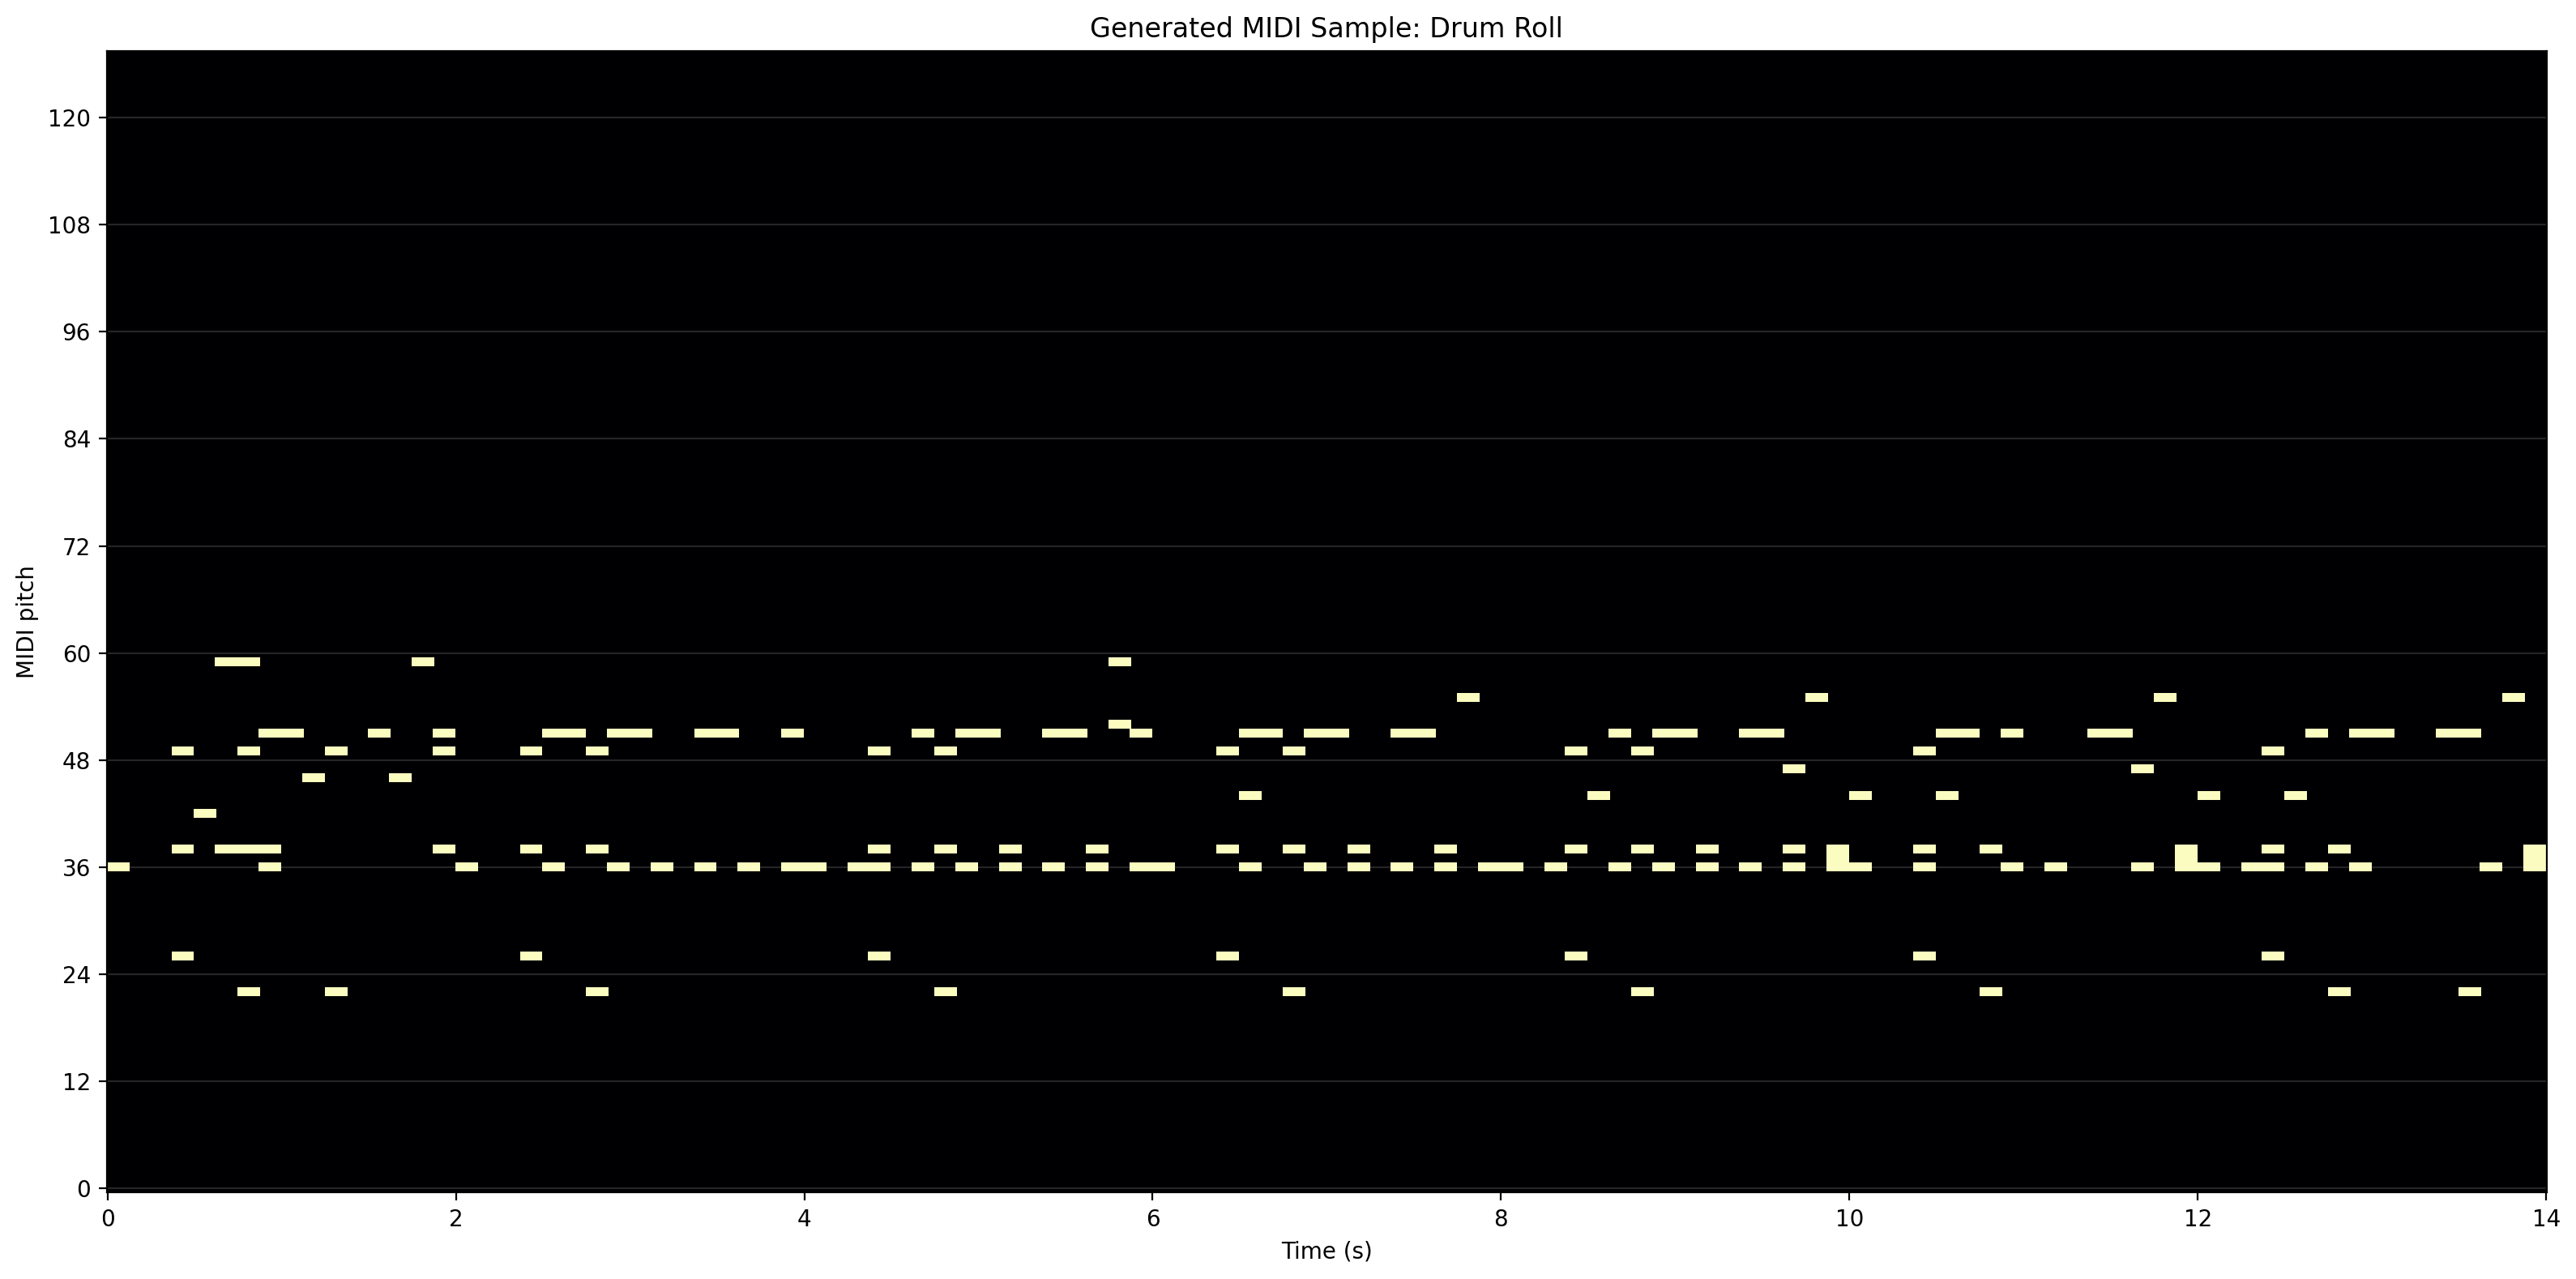

In [ ]:
#@title After you've trained and/or clicked "Run All" at the top.
#@markdown <p>You can adjust the settings below to generate new music with your trained model. You can re-run this cell as many times as you like to generate different music each time!</p>
#@markdown
#@markdown <h2><font size=5 color=blue>How many bars do you want to generate?</font></h2>
N_NUM_BARS_TO_GENERATE = 7 #@param {type:'slider', min:'0', max:'100', step:'1"}
#@markdown <h2><font size=2 color=blue>Go bananas and increase or decreae the level of creativity</font></h2>
CREATIVITY = 1.5 #@param {type:'slider', min:'0.0', max:'2.0', step:'0.1'}

if TRAINING_ON:
    checkpoint_dir = opt.ckpt_dir
    if not os.path.isdir(checkpoint_dir):
        raise FileNotFoundError(f"Checkpoint directory not found: {checkpoint_dir}")

    checkpoint_files = sorted(
        [
            os.path.join(checkpoint_dir, f)
            for f in os.listdir(checkpoint_dir)
            if f.endswith(".pth")
        ]
    )

    if not checkpoint_files:
        raise FileNotFoundError(f"No checkpoint files found in {checkpoint_dir}")

    generated_midi_files = []
    print(f"Found {len(checkpoint_files)} checkpoint files in {checkpoint_dir}")
    for ckpt_path in checkpoint_files:
        ckpt_stem = os.path.splitext(os.path.basename(ckpt_path))[0]
        output_name = f"{MIDI_FILENAME}_{ckpt_stem}"
        print(f"\nGenerating with checkpoint: {ckpt_path}")
        generate_music(
            generator,
            conditioner,
            discriminator,
            opt,
            device,
            NUM_BARS_TO_GENERATE=N_NUM_BARS_TO_GENERATE,
            MIDI_FILENAME=output_name,
            checkpoint_path=ckpt_path,
            creativity=CREATIVITY
        )
        generated_midi_files.append(output_name + ".mid")
else:
    pretrained_path = f"./pretrained_models/{opt.genre}_model_weights.pth"
    if not os.path.isfile(pretrained_path):
        raise FileNotFoundError(f"Pretrained model file not found: {pretrained_path}")

    print(f"Generating with pretrained model: {pretrained_path}")
    generate_music(
        generator,
        conditioner,
        discriminator,
        opt,
        device,
        NUM_BARS_TO_GENERATE=N_NUM_BARS_TO_GENERATE,
        MIDI_FILENAME=MIDI_FILENAME,
        checkpoint_path=pretrained_path,
        creativity=CREATIVITY
    )

# Listen and download your MIDI or audio file!

In [ ]:
#@title Define some more Helper Functions for listening to your beats.
from music21 import converter
import pygame
import time
from midi2audio import FluidSynth
from IPython.display import Audio

def save_audio_file_from_midi(midi_path='generated_sample.mid'):
    output_wav = midi_path.replace('.mid', '.wav')

    pm = pretty_midi.PrettyMIDI(midi_path)
    print(f"PrettyMIDI loaded. Number of instruments: {len(pm.instruments)}")
    print(f"First instrument details: {pm.instruments[0] if pm.instruments else 'No instruments found'}")

    # Keep only the first instrument (remove instrument 1)
    if len(pm.instruments) > 1:
        print(f"Multiple instruments found ({len(pm.instruments)}). Keeping only the first one for audio conversion.")
        pm.instruments = [pm.instruments[0]]

    # pm.write(mod_midi := file_name.replace('.mid', '_modified.mid'))

    soundfont_path = 'FluidR3Mono_GM.sf3'

    # Initialize the synthesizer
    # sample_rate=44100 is standard CD quality
    fs = FluidSynth(sound_font=soundfont_path, sample_rate=44100)

    print(f"Synthesizing audio for {midi_path}...")

    # Render the MIDI file to a WAV file on the Colab disk
    fs.midi_to_audio(midi_path, output_wav)

    print(f"Done! Audio saved to {output_wav}")

    return midi_path, output_wav

def show_midi_score(midi_filepath="generated_sample.mid"):
    """
    Load a MIDI file and display it as notation in the notebook.
    """
    score = converter.parse(midi_filepath)
    try:
        score.show("musicxml")
        plot_midi(midi_filepath, title="MIDI Score Visualization")
    except Exception:
        # Fallback if musicxml rendering is unavailable
        print(score.show("text"))
    return score

def play_drum_midi(midi_path):
    """
    Loads and plays a standard MIDI file using Pygame.
    """
    # Initialize the Pygame audio mixer
    pygame.mixer.init()

    try:
        # Load the file
        pygame.mixer.music.load(midi_path)
        print(f"Playing {midi_path}...")

        # Start playback
        pygame.mixer.music.play()

        # Keep the Python script running while the music plays
        while pygame.mixer.music.get_busy():
            # Wait a fraction of a second, then check again
            time.sleep(0.1)

    except pygame.error as e:
        print(f"Pygame could not play the MIDI file: {e}")
    finally:
        # Free up the audio hardware when finished
        pygame.mixer.quit()

In [ ]:
#@title Select the file you want to listen to
#@markdown NOTE: <p>This may only be one file if you're generating from pretrained models and not training locally.</p>
#@markdown <p>If you want to start training again, go up to the top and start the process over!</p>
if TRAINING_ON:
    midi_files_generated = globals().get("midi_files_generated", globals().get("generated_midi_files", []))

    if midi_files_generated:
        midi_filename = midi_files_generated[0]
        midi_dropdown = widgets.Dropdown(
            options=midi_files_generated,
            value=midi_filename,
            description="MIDI file:",
            layout=widgets.Layout(width="70%")
        )

        def _set_selected_midi(change):
            if change["name"] == "value" and change["new" ] is not None:
                selected_name = change["new"]
                globals()["midi_filename"] = selected_name

                # Dynamically find the checkpoint matching the selected MIDI file
                # Assuming file naming convention: generated_sample_best_genre_model_epoch_X_ID.mid
                if "_best_" in selected_name:
                    checkpoint_identifier = selected_name.split("_best_")[1].replace(".mid", "")
                    matching_files = [f for f in os.listdir(opt.ckpt_dir) if checkpoint_identifier in f and f.endswith(".pth")]

                    if matching_files:
                        checkpoint_path = os.path.join(opt.ckpt_dir, matching_files[0])
                        print(f"Loading weights from: {checkpoint_path}")
                        ckpt = torch.load(checkpoint_path, map_location=device)
                        generator.load_state_dict(ckpt["generator_state_dict"])
                        conditioner.load_state_dict(ckpt["conditioner_state_dict"])
                        discriminator.load_state_dict(ckpt["discriminator_state_dict"])
                    else:
                        print(f"No matching .pth checkpoint found for {selected_name}")

        midi_dropdown.observe(_set_selected_midi, names="value")
        display(midi_dropdown)
    else:
        midi_filename = f"{MIDI_FILENAME}.mid"
        print(f"No generated MIDI list found. Using default: {midi_filename}")
else:
    midi_filename = f"{MIDI_FILENAME}.mid"

PrettyMIDI loaded. Number of instruments: 1
First instrument details: Instrument(program=0, is_drum=True, name="GAN Drum Kit")
Synthesizing audio for generated_sample.mid...
Done! Audio saved to generated_sample.wav


Output()

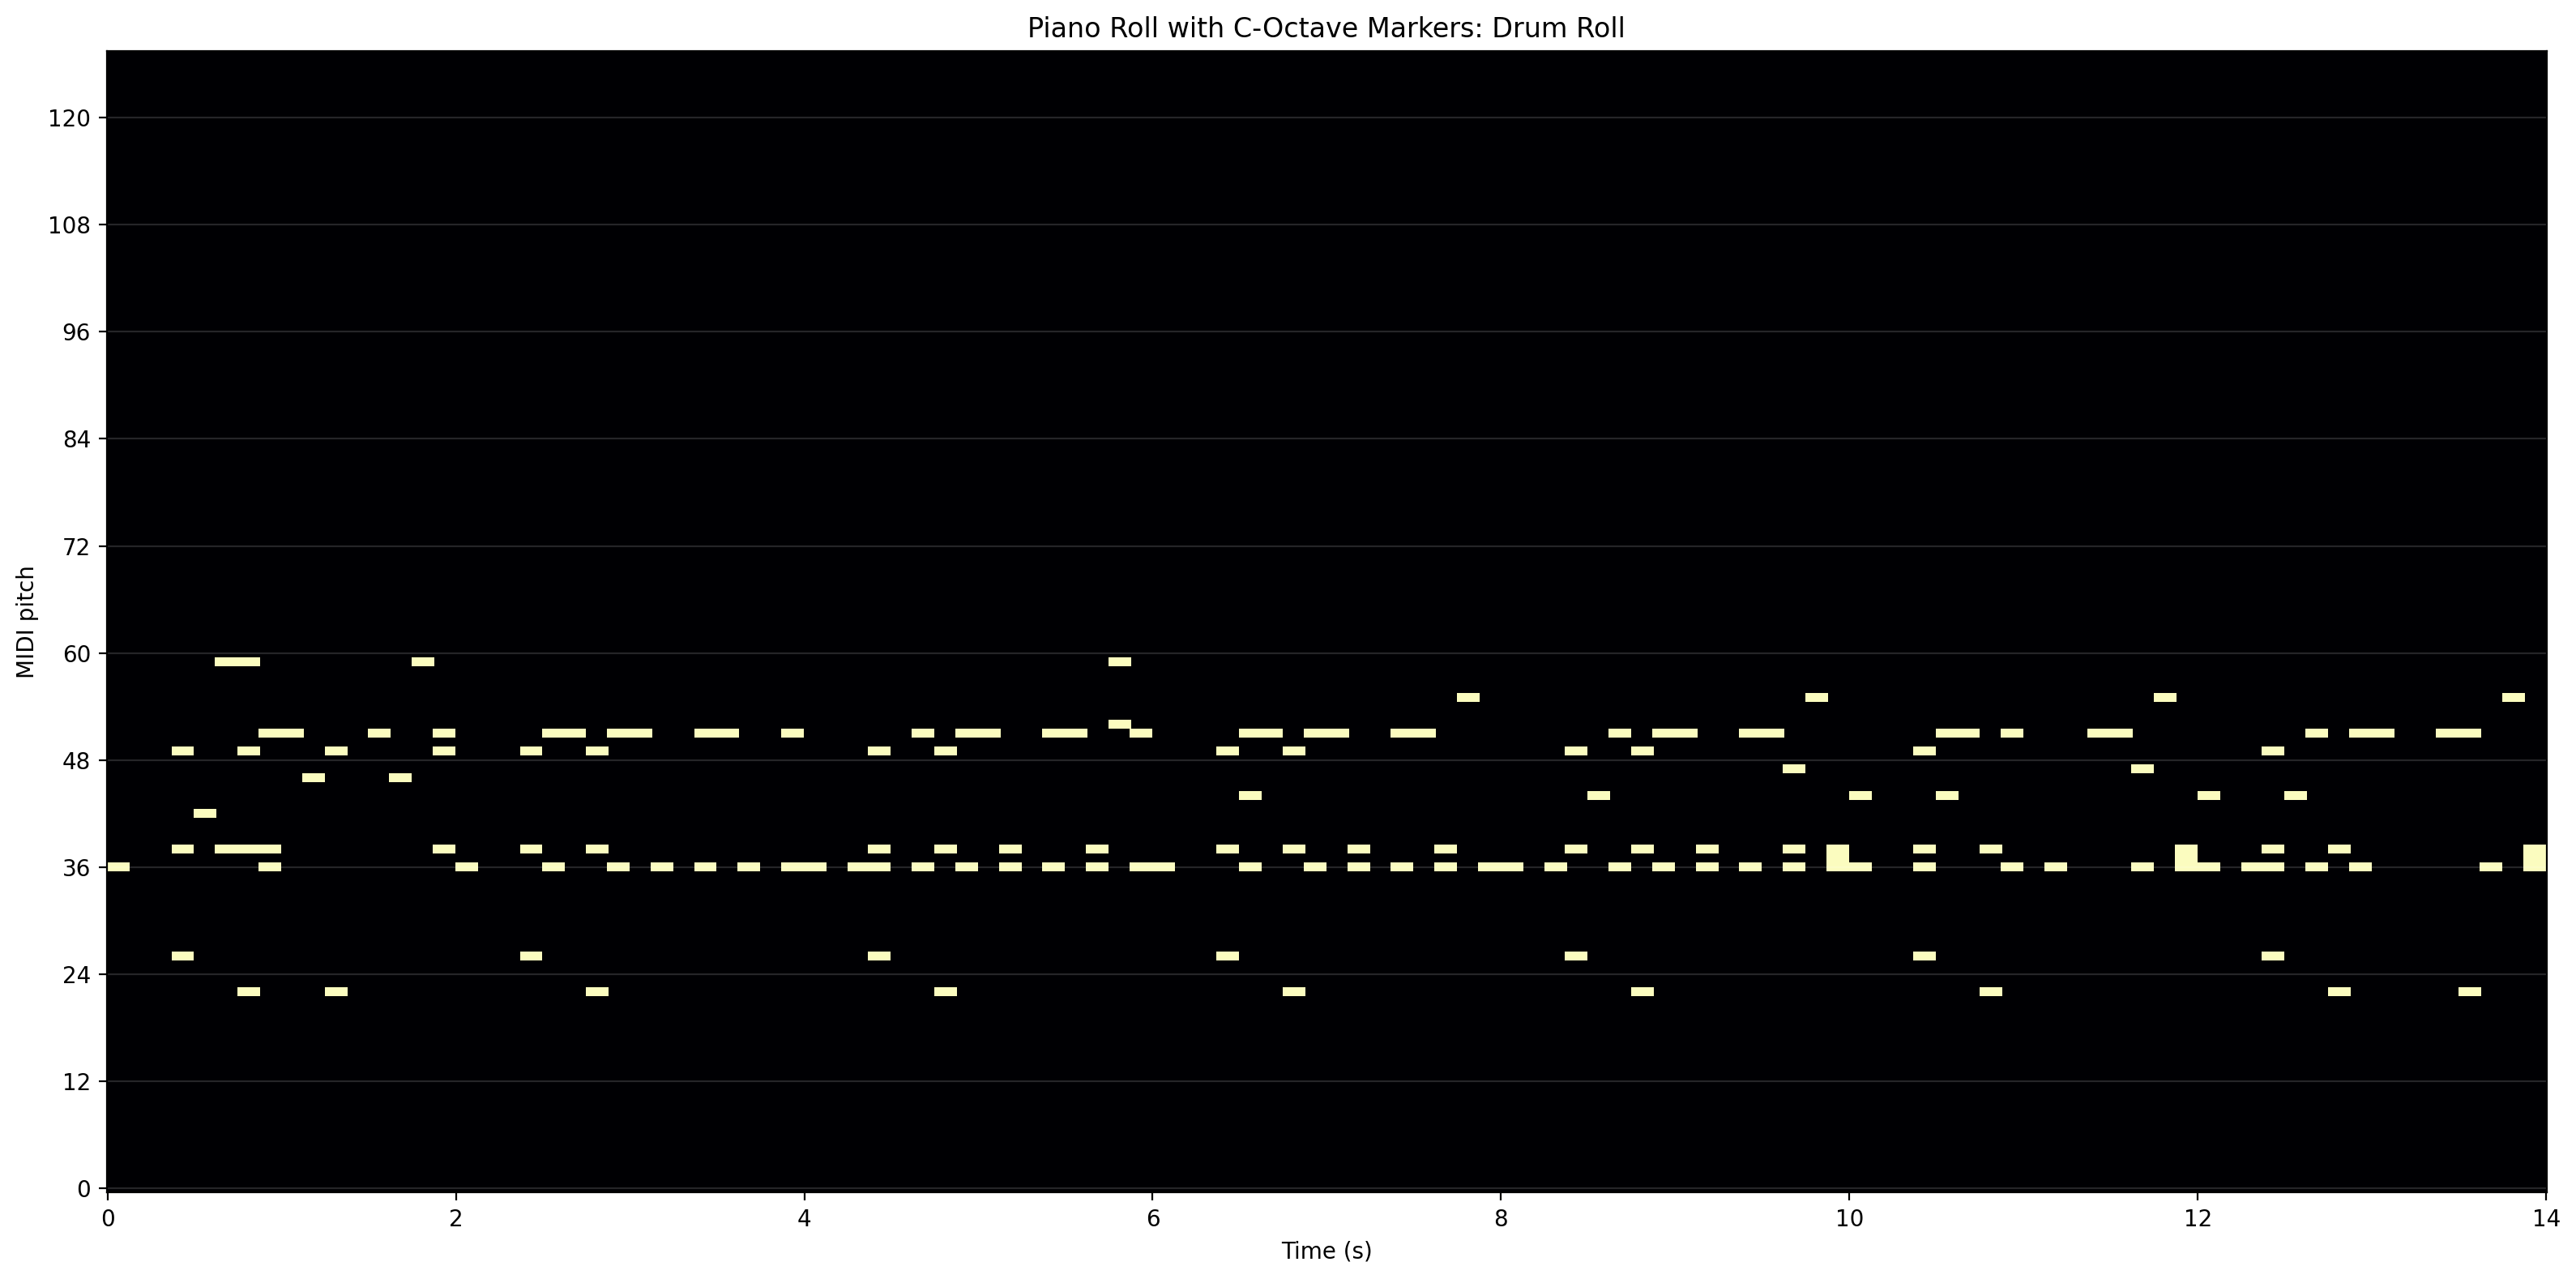

'Printed the piano roll plot successfully.'

In [ ]:
#@title Listen and Download
#@markdown <p>Play the cell so that you can listen to the beat and download a MIDI or .WAV file if you want.</p>
#@markdown <p><b>If you want to train again, please scroll back up to the top, setup the settings the 'Run all'</b></p>
_, wav_path = save_audio_file_from_midi(midi_filename)

display(Audio(wav_path))
if in_colab:
    from google.colab import files
    download_mid_button = widgets.Button(description="Download MIDI", button_style="success")
    download_wav_button = widgets.Button(description="Download WAV", button_style="info")
    download_output = widgets.Output()
    def _download_midi(_):
        with download_output:
            clear_output(wait=True)
            files.download(midi_filename)

    def _download_wav(_):
        with download_output:
            clear_output(wait=True)

            files.download(wav_path)

    download_mid_button.on_click(_download_midi)
    download_wav_button.on_click(_download_wav)
    display(widgets.HBox([download_mid_button, download_wav_button]), download_output)

else:
    print("Colab download UI is available only in Google Colab.")
    # play_drum_midi(midi_filename)

plot_midi(midi_filename)

In [ ]:
from IPython.display import IFrame

# @markdown ## Feedback and Survey Form
# @markdown #### <b>Please complete!</b>
# @markdown Please fill out the google form if you don't mind so that I can gather evaluation data.
FORM_URL = "https://docs.google.com/forms/d/e/1FAIpQLSfnu5JGQv4WunY-2o0htNv2nVT74rNImMMG-AmXS-2NvOmNtw/viewform?usp=dialog"

if FORM_URL:
    display(IFrame(src=FORM_URL, width='100%', height='600px'))
else:
    print("Please provide a Google Form URL in the input field above.")